# DNA transcription factors (TFBS)

## Read data

In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models

# Labels: solo columna 0
labels = pd.read_csv("labels.txt", header=None)
labels_array = labels[0].values  # vector 0/1

# Sequences: cada fila una secuencia
sequences = pd.read_csv("sequences.txt", header=None)
seq_list = sequences[0].astype(str).tolist()  # convertir a lista de strings




2026-03-18 23:44:32.611245: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773873872.622793  502400 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773873872.626699  502400 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-18 23:44:32.638608: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data preparation( one-hot encoding)

In [2]:
onehot_list = []

for s in seq_list:
    # Reemplazo nucleótidos por 4 bits
    s_bin = s.replace('A','1000').replace('C','0100').replace('T','0010').replace('G','0001')

    # Separar bits y convertir a enteros
    bits = [int(b) for b in s_bin]

    onehot_list.append(bits)

# Convertir a matriz numpy
sequences2 = np.array(onehot_list)
print("Shape sequences2:", sequences2.shape)
print(sequences2[:2, :])


Shape sequences2: (2000, 200)
[[0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0
  1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1
  1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0
  0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0
  0 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 1
  1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0]
 [0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0
  0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1
  0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 1 0
  0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 0
  0 0 1 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1
  0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1]]


In [3]:
labels_cat = to_categorical(labels_array, num_classes=2)  # shape (num_sequences, 2)
x = sequences2.reshape((sequences2.shape[0], sequences2.shape[1], 1))  # (num_sequences, len_codificada, 1)
print("Shape x:", x.shape)


Shape x: (2000, 200, 1)


## Model 1

In [4]:
model = models.Sequential([
    layers.Input(shape = (x.shape[1],1)),
    layers.Conv1D(filters=32, kernel_size=12, activation='relu'),
    layers.MaxPooling1D(pool_size=16),
    layers.Flatten(),
    layers.Dense(12, activation='relu'),
    layers.Dense(2, activation='softmax')
])

model.summary()


I0000 00:00:1773873874.499816  502400 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1031 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 189, 32)        │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 11, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 352)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │         4,236 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,678 (18.27 KB)

 Trainable params: 4,678 (18.27 KB)

 Non-trainable params: 0 (0.00 B)

# Training

In [5]:
import numpy as np

# 90% training, 10% validation
perc_training = 0.9
num_train = int(sequences2.shape[0] * perc_training)

x_train = x[:num_train, :, :]  # (num_train, 200, 1)
x_val = x[num_train:, :, :]    # (num_val, 200, 1)

labels_train = labels_cat[:num_train, :]
labels_val = labels_cat[num_train:, :]


In [6]:
from tensorflow.keras.optimizers import RMSprop

model.compile(
    loss='categorical_crossentropy',
    optimizer=RMSprop(),
    metrics=['accuracy']
)
history = model.fit(
    x_train, labels_train,
    epochs=25,
    batch_size=32,
    validation_data=(x_val, labels_val)
)


Epoch 1/25


I0000 00:00:1773873875.406464  502465 service.cc:148] XLA service 0x7ad620005ef0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773873875.406485  502465 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-03-18 23:44:35.421938: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773873875.467620  502465 cuda_dnn.cc:529] Loaded cuDNN version 90800


39/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5117 - loss: 0.6944 

I0000 00:00:1773873876.041640  502465 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5228 - loss: 0.6898 - val_accuracy: 0.6650 - val_loss: 0.6559
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6571 - loss: 0.6504 - val_accuracy: 0.5850 - val_loss: 0.6310
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7282 - loss: 0.6070 - val_accuracy: 0.9000 - val_loss: 0.5501
Epoch 4/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8397 - loss: 0.5385 - val_accuracy: 0.8900 - val_loss: 0.4768
Epoch 5/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8904 - loss: 0.4554 - val_accuracy: 0.7100 - val_loss: 0.4637
Epoch 6/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9295 - loss: 0.3688 - val_accuracy: 0.9250 - val_loss: 0.3088
Epoch 7/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9433 - loss: 0.3011 - val_accuracy: 0.8150 - val_loss: 0.3549
Epoch 8/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9425 - loss: 0.2562 - val_accuracy: 0.9350 - val_loss: 0.2283
Ep

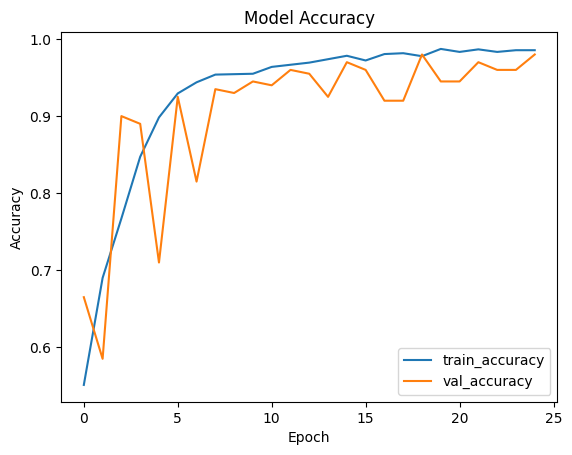

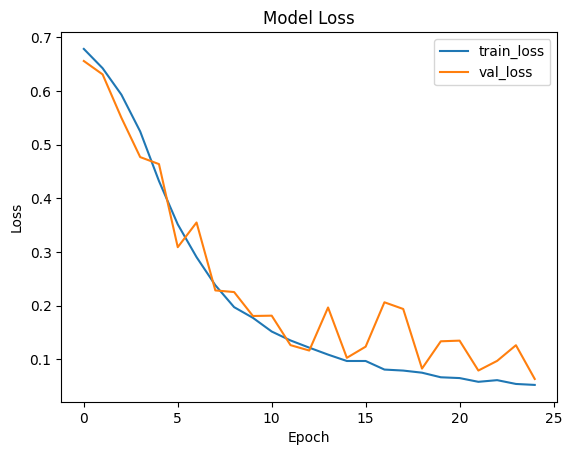

In [7]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


# Predictions

In [8]:
model.evaluate(x_val, labels_val)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9855 - loss: 0.0567 


[0.06318814307451248, 0.9800000190734863]

In [9]:
# Predicciones sobre el conjunto de validación
preds = model.predict(x_val)  # shape (num_val_samples, 2) para softmax

# Mostrar las primeras 6 predicciones
print(preds[:6])


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step 
[[9.9954468e-01 4.5531485e-04]
 [9.9652231e-01 3.4777715e-03]
 [9.9563521e-01 4.3647354e-03]
 [1.9228644e-03 9.9807715e-01]
 [9.5319195e-04 9.9904674e-01]
 [9.9981004e-01 1.9002630e-04]]
